# Publications by year

Counts the publication list and plots three lines per year (2019–2026):

- **First-author papers** — entries with *Santoliquido* as first author (bold in the source list)
- **LVK papers** — entries authored by *The LIGO Scientific Collaboration*
- **All the rest** — everything else

The list is embedded below, so the notebook is fully self-contained. To update, just edit the `RAW` string (keep the `# YYYY` year headers and one `*...*` line per paper).

In [7]:
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

In [2]:
plt.rcParams.update({
    "text.usetex": True,          # use a real LaTeX install
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,              # base size — bump everything up
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

In [3]:
RAW = r'''
# 2026

*GWTC-5.0: An Introduction to Version 5.0 of the Gravitational-Wave Transient Catalog*, The LIGO Scientific Collaboration et al., arXiv 05/2026.
*GW240925 and GW250207: Astrophysical Calibration of Gravitational-wave Detectors*, The LIGO Scientific Collaboration et al., arXiv 05/2026.
*Searches for Binary Mergers with Sub-solar Mass Components in Data from the First Part of LIGO--Virgo--KAGRA's Fourth Observing Run*, The LIGO Scientific Collaboration et al., arXiv 05/2026.
*Deep Search for Joint Sources of Gravitational Waves and High-energy Neutrinos with IceCube during the Third Observing Run of LIGO and Virgo*, Abbasi et al., ApJ 1003(1), 05/2026.
*Comparing astrophysical models to gravitational-wave data in the observable space*, Toubiana et al., PhRvD 113(8), 04/2026.
*All-sky search for long-duration gravitational-wave transients in the first part of the fourth LIGO-Virgo-KAGRA observing run*, Abac et al., PhRvD 113(8), 04/2026.
*Comparing next-generation detector configurations for high-redshift gravitational wave sources with neural posterior estimation*, **Santoliquido et al.**, A&A 708 04/2026.
*Narrowband searches for continuous gravitational waves from known pulsars in the first two parts of the fourth LIGO--Virgo--KAGRA observing run*, The LIGO Scientific Collaboration et al., arXiv 03/2026.
*Searches for Continuous Gravitational Waves from Supernova Remnants in the first part of the LIGO-Virgo-KAGRA Fourth Observing run*, The LIGO Scientific Collaboration et al., arXiv 03/2026.
*Isolated or Dynamical? Tracing Black Hole Binary Formation through the Population of Gravitational-Wave Sources*, Arca Sedda et al., arXiv 03/2026.
*Advanced Virgo Plus for O5 -- Design Report Overview*, Acernese et al., arXiv 03/2026.
*GWTC-4.0: Tests of General Relativity. III. Tests of the Remnants*, The LIGO Scientific Collaboration et al., arXiv 03/2026.
*GWTC-4.0: Tests of General Relativity. II. Parameterized Tests*, The LIGO Scientific Collaboration et al., arXiv 03/2026.
*GWTC-4.0: Tests of General Relativity. I. Overview and General Tests*, The LIGO Scientific Collaboration et al., arXiv 03/2026.
*Calibrating spectral siren cosmology with synthetic catalogs of binary black hole mergers*, Scarpa et al., arXiv 03/2026.
*All-sky Searches for Continuous Gravitational Waves from Isolated Neutron Stars in the Data from the First Part of the Fourth LIGO-Virgo-KAGRA Observing Run*, The LIGO Scientific Collaboration et al., arXiv 03/2026.
*The Science of the Einstein Telescope*, Abac et al., JCAP 2026(3), 03/2026.
*Constraining Binary Neutron Star Populations using Short Gamma-Ray Burst Observations*, De Santis et al., arXiv 02/2026.
*Black Hole Spectroscopy and Tests of General Relativity with GW250114*, Abac et al., PhRvL 136(4), 01/2026.
*Crystal Eye: All sky MeV monitor with high precision real-time localization*, Aloisio et al., APh 174 01/2026.

# 2025

*WINK: Advancing X and Gamma Ray Detection Technology for Space Observations*, Tambone et al., icrc.conf 12/2025.
*X-ray Binaries: A Key Corollary Science with Crystal Eye*, Tarana et al., icrc.conf 12/2025.
*Constraints on gravitational waves from the 2024 Vela pulsar glitch*, The LIGO Scientific Collaboration et al., arXiv 12/2025.
*Uncovering the population of compact binary mergers and their formation pathways with gravitational waves through the Einstein Telescope*, Arca-Sedda et al., arXiv 12/2025.
*GWTC-4.0: Searches for Gravitational-Wave Lensing Signatures*, The LIGO Scientific Collaboration et al., arXiv 12/2025.
*GWTC-4.0: An Introduction to Version 4.0 of the Gravitational-Wave Transient Catalog*, Abac et al., ApJL 995(1), 12/2025.
*Black hole-neutron star and binary neutron star mergers from Population III and II stars*, Mestichelli et al., A&A 704 12/2025.
*Search for planetary-mass ultra-compact binaries using data from the first part of the LIGO--Virgo--KAGRA fourth observing run*, The LIGO Scientific Collaboration et al., arXiv 11/2025.
*All-sky search for continuous gravitational-wave signals from unknown neutron stars in binary systems in the first part of the fourth LIGO-Virgo-KAGRA observing run*, The LIGO Scientific Collaboration et al., arXiv 11/2025.
*Fast and accurate parameter estimation of high-redshift sources with the Einstein Telescope*, **Santoliquido et al.**, PhRvD 112(10), 11/2025.
*All-sky search for short gravitational-wave bursts in the first part of the fourth LIGO-Virgo-KAGRA observing run*, Abac et al., PhRvD 112(10), 11/2025.
*GW231123: A Binary Black Hole Merger with Total Mass 190-265 Msun*, Abac et al., ApJL 993(1), 11/2025.
*GW241011 and GW241110: Exploring Binary Formation and Fundamental Physics with Asymmetric, High-spin Black Hole Coalescences*, Abac et al., ApJL 993(1), 11/2025.
*Direct multi-model dark-matter search with gravitational-wave interferometers using data from the first part of the fourth LIGO-Virgo-KAGRA observing run*, The LIGO Scientific Collaboration et al., arXiv 10/2025.
*Cosmological and High Energy Physics implications from gravitational-wave background searches in LIGO-Virgo-KAGRA's O1-O4a runs*, The LIGO Scientific Collaboration et al., arXiv 10/2025.
*Directional Search for Persistent Gravitational Waves: Results from the First Part of LIGO-Virgo-KAGRA's Fourth Observing Run*, The LIGO Scientific Collaboration et al., arXiv 10/2025.
*Directed searches for gravitational waves from ultralight vector boson clouds around merger remnant and galactic black holes during the first part of the fourth LIGO-Virgo-KAGRA observing run*, The LIGO Scientific Collaboration et al., arXiv 09/2025.
*GWTC-4.0: Constraints on the Cosmic Expansion Rate and Modified Gravitational-wave Propagation*, The LIGO Scientific Collaboration et al., arXiv 09/2025.
*GW250114: Testing Hawking's Area Law and the Kerr Nature of Black Holes*, Abac et al., PhRvL 135(11), 09/2025.
*Upper Limits on the Isotropic Gravitational-Wave Background from the first part of LIGO, Virgo, and KAGRA's fourth Observing Run*, The LIGO Scientific Collaboration et al., arXiv 08/2025.
*GWTC-4.0: Population Properties of Merging Compact Binaries*, The LIGO Scientific Collaboration et al., arXiv 08/2025.
*GWTC-4.0: Updating the Gravitational-Wave Transient Catalog with Observations from the First Part of the Fourth LIGO-Virgo-KAGRA Observing Run*, The LIGO Scientific Collaboration et al., arXiv 08/2025.
*GWTC-4.0: Methods for Identifying and Characterizing Gravitational-wave Transients*, The LIGO Scientific Collaboration et al., arXiv 08/2025.
*Open Data from LIGO, Virgo, and KAGRA through the First Part of the Fourth Observing Run*, The LIGO Scientific Collaboration et al., arXiv 08/2025.
*Search for Gravitational Waves Emitted from SN 2023ixf*, Abac et al., ApJ 985(2), 06/2025.
*The more accurately the metal-dependent star formation rate is modeled, the larger the predicted excess of binary black hole mergers*, Sgalletta et al., A&A 698 06/2025.
*Prospects for optical detections from binary neutron star mergers with the next-generation multi-messenger observatories*, Loffredo et al., A&A 697 05/2025.
*Search for Continuous Gravitational Waves from Known Pulsars in the First Part of the Fourth LIGO-Virgo-KAGRA Observing Run*, Abac et al., ApJ 983(2), 04/2025.
*A new prescription for the spectral properties of population III stellar populations*, Lecroq et al., A&A 695 03/2025.
*Validating prior-informed Fisher-matrix analyses against GWTC data*, Dupletsa et al., PhRvD 111(2), 01/2025.

# 2024

*A Search Using GEO600 for Gravitational Waves Coincident with Fast Radio Bursts from SGR 1935+2154*, Abac et al., ApJ 977(2), 12/2024.
*Gravitational waves from mergers of Population III binary black holes: roles played by two evolution channels*, Liu et al., MNRAS 534(3), 11/2024.
*Classifying binary black holes from Population III stars with the Einstein Telescope: A machine-learning approach*, **Santoliquido et al.**, A&A 690 10/2024.
*Binary black hole mergers from Population III star clusters*, Mestichelli et al., A&A 690 10/2024.
*Observation of Gravitational Waves from the Coalescence of a 2.5-4.5 Msun Compact Object and a Neutron Star*, Abac et al., ApJL 970(2), 08/2024.
*Correction to: Binary black hole mergers from population III stars: uncertainties from star formation and binary star properties*, **Santoliquido et al.**, MNRAS 528(1), 02/2024.

# 2023

*Binary Black Hole Spins: Model Selection with GWTC-3*, Perigois et al., Univ 9(12), 12/2023.
*Massive binary black holes from Population II and III stars*, Costa et al., MNRAS 525(2), 10/2023.
*Pre-merger alert to detect prompt emission in very-high-energy gamma-rays from binary neutron star mergers: Einstein Telescope and Cherenkov Telescope Array synergy*, Banerjee et al., A&A 678 10/2023.
*Compact object mergers: exploring uncertainties from stellar and binary evolution with SEVN*, Iorio et al., MNRAS 524(1), 09/2023.
*Binary black hole mergers from population III stars: uncertainties from star formation and binary star properties*, **Santoliquido et al.**, MNRAS 524(1), 09/2023.
*Science with the Einstein Telescope: a comparison of different designs*, Branchesi et al., JCAP 2023(7), 07/2023.

# 2022

*Modelling the host galaxies of binary compact object mergers with observational scaling relations*, **Santoliquido et al.**, MNRAS 516(3), 11/2022.
*Perspectives for multimessenger astronomy with the next generation of gravitational-wave detectors and high-energy satellites*, Ronchini et al., A&A 665 09/2022.
*Erratum: Prospects for multimessenger detection of binary neutron star mergers in the fourth LIGO-Virgo-KAGRA observing run*, Patricelli et al., MNRAS 514(3), 08/2022.
*The evolution of compact object mergers and their host galaxies across cosmic time*, **Santoliquido et al.**, eas..conf 07/2022.
*Prospects for multi-messenger detection of binary neutron star mergers in the fourth LIGO-Virgo-KAGRA observing run*, Patricelli et al., eas..conf 07/2022.
*Prospects for multimessenger detection of binary neutron star mergers in the fourth LIGO-Virgo-KAGRA observing run*, Patricelli et al., MNRAS 513(3), 07/2022.
*Gravitational background from dynamical binaries and detectability with 2G detectors*, Perigois et al., PhRvD 105(10), 05/2022.
*Host galaxies and electromagnetic counterparts to binary neutron star mergers across the cosmic time: detectability of GW170817-like events*, Perna et al., MNRAS 512(2), 05/2022.
*The cosmic evolution of binary black holes in young, globular, and nuclear star clusters: rates, masses, spins, and mixing fractions*, Mapelli et al., MNRAS 511(4), 04/2022.
*The evolution of compact object mergers and their host galaxies across cosmic time*, **Santoliquido et al.**, APS..APRD 2022 04/2022.
*Compact object mergers in hierarchical triples from low-mass young star clusters*, Trani et al., MNRAS 511(1), 02/2022.

# 2021

*GW190521 formation via three-body encounters in young massive star clusters*, Dall'Amico et al., MNRAS 508(2), 12/2021.
*New insights on binary black hole formation channels after GWTC-2: young star clusters versus isolated binaries*, Bouffanais et al., MNRAS 507(4), 11/2021.
*Dynamics of binary black holes in low-mass young star clusters*, Rastello et al., MNRAS 507(3), 11/2021.
*Mass and Rate of Hierarchical Black Hole Mergers in Young, Globular and Nuclear Star Clusters*, Mapelli et al., Symm 13(9), 09/2021.
*Constraining accretion efficiency in massive binary stars with LIGO -Virgo black holes*, Bouffanais et al., MNRAS 505(3), 08/2021.
*Hierarchical black hole mergers in young, globular and nuclear star clusters: the effect of metallicity, spin and cluster properties*, Mapelli et al., MNRAS 505(1), 07/2021.
*The cosmic merger rate density of compact objects: impact of star formation, metallicity, initial mass function, and binary evolution*, **Santoliquido et al.**, MNRAS 502(4), 04/2021.

# 2020

*Binary black holes in young star clusters: the impact of metallicity*, Di Carlo et al., MNRAS 498(1), 10/2020.
*Dynamics of black hole-neutron star binaries in young star clusters*, Rastello et al., MNRAS 497(2), 09/2020.
*Binary black holes in the pair instability mass gap*, Di Carlo et al., MNRAS 497(1), 09/2020.
*The Cosmic Merger Rate Density Evolution of Compact Binaries Formed in Young Star Clusters and in Isolated Binaries*, **Santoliquido et al.**, ApJ 898(2), 08/2020.
*An astrophysically motivated ranking criterion for low-latency electromagnetic follow-up of gravitational wave events*, Artale et al., MNRAS 495(2), 06/2020.

# 2019

*Host galaxies of merging compact objects: mass, star formation rate, metallicity, and colours*, Artale et al., MNRAS 487(2), 08/2019.
*The properties of merging black holes and neutron stars across cosmic time*, Mapelli et al., MNRAS 487(1), 07/2019.
'''

In [5]:
def classify(line):
    if "**Santoliquido et al.**" in line:
        return "first"
    lvk_tags = ["The LIGO Scientific Collaboration", "Abac et al.",
                "Abbasi et al.", "Acernese et al."]
    if any(tag in line for tag in lvk_tags):
        return "lvk"
    return "rest"

counts = defaultdict(lambda: {"first": 0, "lvk": 0, "rest": 0})
year = None
for line in RAW.splitlines():
    line = line.strip()
    m = re.match(r"^#\s*(\d{4})\s*$", line)
    if m:
        year = int(m.group(1))
        continue
    if year is not None and line.startswith("*"):
        counts[year][classify(line)] += 1

# Print a quick summary table
print(f"{'year':>5} {'first':>6} {'lvk':>5} {'rest':>5} {'total':>6}")
for y in sorted(counts):
    c = counts[y]
    print(f"{y:>5} {c['first']:>6} {c['lvk']:>5} {c['rest']:>5} {sum(c.values()):>6}")

 year  first   lvk  rest  total
 2019      0     0     2      2
 2020      1     0     4      5
 2021      1     0     6      7
 2022      3     0     8     11
 2023      1     0     5      6
 2024      2     2     2      6
 2025      1    21     8     30
 2026      1    14     5     20


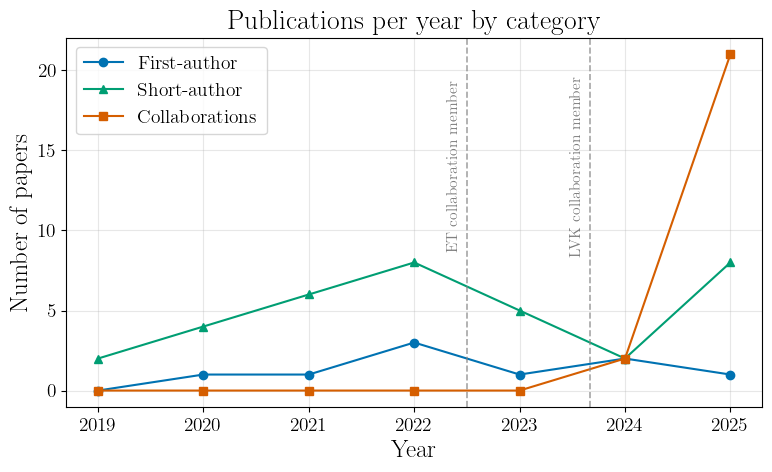

In [11]:
years = list(range(2019, 2026))
first = [counts[y]["first"] for y in years]
lvk   = [counts[y]["lvk"]   for y in years]
rest  = [counts[y]["rest"]  for y in years]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(years, first, marker="o", label="First-author", color="#0072B2",)
ax.plot(years, rest,  marker="^", label="Short-author", color="#009E73",)
ax.plot(years, lvk,   marker="s", label="Collaborations",  color="#D55E00",)


# x = year + (month-1)/12
x_et  = 2022 + 6/12   # July 2022  -> 2022.5
x_lvk = 2023 + 8/12   # September 2023 -> ~2023.67

for x in (x_et, x_lvk):
    ax.axvline(x, color="gray", ls="--", lw=1.2, alpha=0.7)

# blended transform: x in data units, y in axes fraction (0=bottom, 1=top)
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

ax.text(x_et - 0.06, 0.65, "ET collaboration member",
        rotation=90, va="center", ha="right",
        transform=trans, color="gray", fontsize=11)
ax.text(x_lvk - 0.06, 0.65, "LVK collaboration member",
        rotation=90, va="center", ha="right",
        transform=trans, color="gray", fontsize=11)

ax.set_xlabel("Year")
ax.set_ylabel("Number of papers")
ax.set_title("Publications per year by category")
ax.set_xticks(years)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

fig.savefig("publications_per_year.png", dpi=150)
plt.show()